In [2]:
pip install torchvision

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---- ----------------------------------- 0.4/3.7 MB 8.1 MB/s eta 0:00:01
   ----------- ---------------------------- 1.1/3.7 MB 11.2 MB/s eta 0:00:01
   --------------------- ------------------ 2.1/3.7 MB 14.5 MB/s eta 0:00:01
   ------------------------------ --------- 2.9/3.7 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------  3.7/3.7 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 15.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.2/123.0 MB 4.6 MB/s eta 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ── 0. Auto-install dependencies ─────────────────────────────────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
 
print("Checking dependencies...")
for pkg in ["numpy", "matplotlib", "torch", "torchvision", "tqdm"]:
    try:
        __import__(pkg)
        print(f"  {pkg} already installed")
    except ImportError:
        print(f"  Installing {pkg}...")
        install(pkg)
 
# ── 1. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os
 

Checking dependencies...
  numpy already installed
  matplotlib already installed
  torch already installed
  torchvision already installed
  Installing tqdm...


In [7]:
print("\n── Downloading MNIST ──")
from torchvision.datasets import MNIST
from torchvision import transforms
 
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)
 
mnist_train = MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
mnist_test = MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)
print(f"  Train samples: {len(mnist_train)}")
print(f"  Test  samples: {len(mnist_test)}")


── Downloading MNIST ──


100.0%
100.0%
100.0%
100.0%


  Train samples: 60000
  Test  samples: 10000


In [8]:
print("""
── N-MNIST (neuromorphic MNIST) ──
N-MNIST requires a manual download (free, just needs registration):
  1. Go to: https://www.garrickorchard.com/datasets/n-mnist
  2. Download Train.zip and Test.zip
  3. Unzip into: ./data/NMNIST/Train/ and ./data/NMNIST/Test/
 
Once downloaded, load it with SpikingJelly (Phase 3):
  from spikingjelly.activation_based.dataset import NMNIST
  train_set = NMNIST(root='./data/NMNIST', train=True,
                     data_type='frame', frames_number=10,
                     split_by='number')
 
DVS128 Gesture (fully neuromorphic, for Phase 5):
  https://research.ibm.com/interactive/dvsgesture/
  Unzip into: ./data/DVS128Gesture/
 
CIFAR10-DVS (auto-downloads via SpikingJelly):
  from spikingjelly.activation_based.dataset import CIFAR10DVS
  train_set = CIFAR10DVS(root='./data/CIFAR10DVS', data_type='frame',
                          frames_number=10, split_by='number')
""")


── N-MNIST (neuromorphic MNIST) ──
N-MNIST requires a manual download (free, just needs registration):
  1. Go to: https://www.garrickorchard.com/datasets/n-mnist
  2. Download Train.zip and Test.zip
  3. Unzip into: ./data/NMNIST/Train/ and ./data/NMNIST/Test/

Once downloaded, load it with SpikingJelly (Phase 3):
  from spikingjelly.activation_based.dataset import NMNIST
  train_set = NMNIST(root='./data/NMNIST', train=True,
                     data_type='frame', frames_number=10,
                     split_by='number')

DVS128 Gesture (fully neuromorphic, for Phase 5):
  https://research.ibm.com/interactive/dvsgesture/
  Unzip into: ./data/DVS128Gesture/

CIFAR10-DVS (auto-downloads via SpikingJelly):
  from spikingjelly.activation_based.dataset import CIFAR10DVS
  train_set = CIFAR10DVS(root='./data/CIFAR10DVS', data_type='frame',
                          frames_number=10, split_by='number')



In [12]:
class LIFNeuron:
    """
    Single leaky integrate-and-fire neuron.
    Simulates membrane potential V over time using Euler integration.
    """
    def __init__(self, tau=20.0, V_th=15.0, V_reset=0.0, t_ref=5.0, dt=0.5):
        self.tau    = tau      # membrane time constant (ms)
        self.V_th   = V_th     # spike threshold (mV above rest)
        self.V_reset = V_reset # reset potential after spike
        self.t_ref  = t_ref    # refractory period (ms)
        self.dt     = dt       # time step (ms)
 
    def simulate(self, I, T=500):
        """
        Run the neuron for T ms with input current I (scalar or array of shape (T,)).
        Returns V (membrane potential over time) and spikes (boolean array).
        """
        steps = int(T / self.dt)
        V      = np.zeros(steps)
        spikes = np.zeros(steps, dtype=bool)
        ref_timer = 0.0
 
        # Allow constant or time-varying input
        I_arr = np.full(steps, I) if np.isscalar(I) else np.asarray(I)
 
        for t in range(1, steps):
            if ref_timer > 0:
                V[t] = self.V_reset
                ref_timer -= self.dt
            else:
                # Euler step: dV/dt = (-V + I) / tau
                dV = (-V[t-1] + I_arr[t-1]) / self.tau * self.dt
                V[t] = V[t-1] + dV
                if V[t] >= self.V_th:
                    spikes[t] = True
                    V[t] = self.V_reset
                    ref_timer = self.t_ref
 
        return V, spikes
 
 
class LIFLayer:
    """
    Vectorised population of N LIF neurons.
    All neurons updated in parallel — no Python loop over neurons.
    """
    def __init__(self, N, tau=20.0, V_th=15.0, V_reset=0.0, t_ref=5.0, dt=0.5):
        self.N      = N
        self.tau    = tau
        self.V_th   = V_th
        self.V_reset = V_reset
        self.t_ref  = t_ref
        self.dt     = dt
        self.reset()
 
    def reset(self):
        self.V          = np.zeros(self.N)
        self.ref_timers = np.zeros(self.N)
 
    def step(self, I):
        """
        One timestep forward.
        I: input current array of shape (N,)
        Returns: spike array of shape (N,) with 1.0 where neurons fired
        """
        active = self.ref_timers <= 0
        self.V[active] += (-self.V[active] + I[active]) / self.tau * self.dt
        fired = self.V >= self.V_th
        self.V[fired]          = self.V_reset
        self.ref_timers[fired] = self.t_ref
        self.ref_timers        = np.maximum(0, self.ref_timers - self.dt)
        return fired.astype(float)
 

In [13]:
# ── 5. Spike Encoders (Phase 2) ───────────────────────────────────────────────
class SpikeEncoder:
    """
    Converts real-valued inputs (e.g. pixel intensities in [0,1])
    into spike trains using three biologically-inspired methods.
    """
 
    def __init__(self, method="rate", T=100):
        """
        method: 'rate' | 'temporal' | 'population'
        T:      number of timesteps in the output spike train
        """
        assert method in ("rate", "temporal", "population"), \
            "method must be 'rate', 'temporal', or 'population'"
        self.method = method
        self.T      = T
 
    def encode(self, x):
        """
        Encode a single sample.
        x:   1D numpy array of shape (N_features,), values in [0, 1]
        Returns spike train of shape (T, N_features)
                or (T, N_features * N_pop) for population coding
        """
        x = np.clip(x, 0.0, 1.0)
 
        if self.method == "rate":
            return self._rate(x)
        elif self.method == "temporal":
            return self._temporal(x)
        elif self.method == "population":
            return self._population(x)
 
    # ── Rate coding ──────────────────────────────────────────────────────────
    def _rate(self, x):
        """
        Each timestep: fire with probability = input value.
        High value → many spikes. Low value → few spikes.
        Shape: (T, N_features)
        """
        return (np.random.rand(self.T, len(x)) < x).astype(float)
 
    # ── Temporal (time-to-first-spike) coding ─────────────────────────────────
    def _temporal(self, x):
        """
        Value encoded in WHEN the spike fires.
        High value → spike early.  Low value → spike late.
        Formula: t_spike = round((1 - x) * (T - 1))
        Shape: (T, N_features)
        """
        spike_times = np.round((1.0 - x) * (self.T - 1)).astype(int)
        spike_times = np.clip(spike_times, 0, self.T - 1)
        out = np.zeros((self.T, len(x)))
        out[spike_times, np.arange(len(x))] = 1.0
        return out
 
    # ── Population coding ─────────────────────────────────────────────────────
    def _population(self, x, N_pop=10):
        """
        Each feature is represented by a bank of N_pop neurons,
        each with a Gaussian tuning curve centered at a different value.
        Neuron closest to input fires strongest.
        Shape: (T, N_features * N_pop)
        """
        centers = np.linspace(0, 1, N_pop)
        sigma   = 1.0 / N_pop * 2.5
        # activations shape: (N_features, N_pop)
        activations = np.exp(-0.5 * ((x[:, None] - centers) / sigma) ** 2)
        acts_flat   = activations.flatten()  # (N_features * N_pop,)
        return (np.random.rand(self.T, len(acts_flat)) < acts_flat).astype(float)
 
    def encode_batch(self, X):
        """
        Encode a batch of samples.
        X:   2D array of shape (batch_size, N_features)
        Returns array of shape (batch_size, T, N_features)
        """
        return np.stack([self.encode(x) for x in X])
 

In [14]:
print("── Loading MNIST samples ──")
images, labels = [], []
for i in range(500):
    img, lbl = mnist_train[i]
    images.append(img.numpy().flatten())   # (784,)
    labels.append(lbl)
images = np.array(images)   # (500, 784)
labels = np.array(labels)
print(f"  Loaded {len(images)} samples, shape: {images.shape}")
 
 
# ── 7. Verification ───────────────────────────────────────────────────────────
print("\n── Verifying rate encoder ──")
encoder = SpikeEncoder(method="rate", T=1000)
test_values = [0.2, 0.5, 0.8]
for v in test_values:
    spike_train = encoder.encode(np.array([v]))
    measured    = spike_train.mean()
    error       = abs(v - measured)
    status      = "PASS" if error < 0.02 else "FAIL"
    print(f"  [{status}] Input: {v:.1f} | Measured rate: {measured:.3f} | Error: {error:.4f}")
 
print("\n── Verifying temporal encoder ──")
enc_t = SpikeEncoder(method="temporal", T=100)
for v in test_values:
    st = enc_t.encode(np.array([v]))
    spike_time = np.argmax(st[:, 0])
    expected   = round((1 - v) * 99)
    status     = "PASS" if spike_time == expected else "FAIL"
    print(f"  [{status}] Input: {v:.1f} | Spike at t={spike_time} | Expected t={expected}")
 
print("\n── F-I curve check ──")
neuron  = LIFNeuron()
currents     = np.linspace(0, 30, 50)
firing_rates = []
for I in currents:
    _, spikes = neuron.simulate(I, T=1000)
    firing_rates.append(spikes.sum() / 1.0)   # spikes per second
print(f"  Max firing rate: {max(firing_rates):.0f} Hz at I=30")
print(f"  Rheobase (min I to fire): ~{currents[next(i for i,r in enumerate(firing_rates) if r>0)]:.1f}")

── Loading MNIST samples ──
  Loaded 500 samples, shape: (500, 784)

── Verifying rate encoder ──
  [PASS] Input: 0.2 | Measured rate: 0.208 | Error: 0.0080
  [PASS] Input: 0.5 | Measured rate: 0.486 | Error: 0.0140
  [PASS] Input: 0.8 | Measured rate: 0.785 | Error: 0.0150

── Verifying temporal encoder ──
  [PASS] Input: 0.2 | Spike at t=79 | Expected t=79
  [PASS] Input: 0.5 | Spike at t=50 | Expected t=50
  [PASS] Input: 0.8 | Spike at t=20 | Expected t=20

── F-I curve check ──
  Max firing rate: 52 Hz at I=30
  Rheobase (min I to fire): ~15.3



── Generating plots ──
  Plots saved to: ./snn_phase2_plots.png


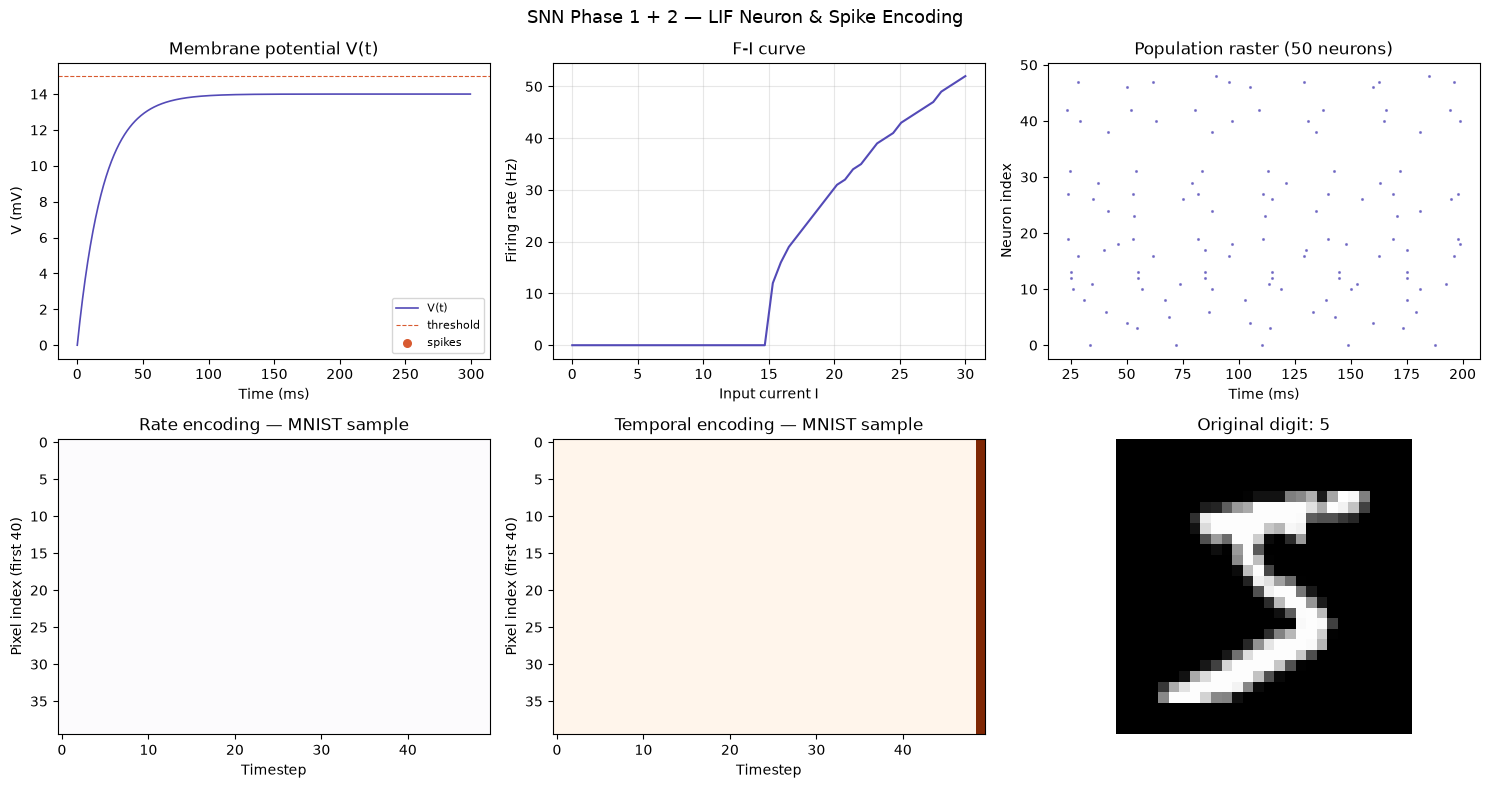


── Done! ──
Next steps:
  Phase 3: pip install spikingjelly
  Then load N-MNIST with SpikingJelly's built-in dataset loader


In [15]:
print("\n── Generating plots ──")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("SNN Phase 1 + 2 — LIF Neuron & Spike Encoding", fontsize=13)
 
# ── Plot 1: Membrane potential ──
ax = axes[0, 0]
neuron  = LIFNeuron()
V, spikes_bool = neuron.simulate(I=14, T=300)
t_axis  = np.arange(len(V)) * 0.5
ax.plot(t_axis, V, color="#534AB7", lw=1.2, label="V(t)")
ax.axhline(15, color="#D85A30", lw=0.8, linestyle="--", label="threshold")
spike_times = t_axis[spikes_bool]
ax.scatter(spike_times, np.full_like(spike_times, 15),
           color="#D85A30", s=30, zorder=5, label="spikes")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("V (mV)")
ax.set_title("Membrane potential V(t)")
ax.legend(fontsize=8)
 
# ── Plot 2: F-I curve ──
ax = axes[0, 1]
ax.plot(currents, firing_rates, color="#534AB7", lw=1.5)
ax.set_xlabel("Input current I")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("F-I curve")
ax.grid(alpha=0.3)
 
# ── Plot 3: Population raster ──
ax = axes[0, 2]
layer = LIFLayer(N=50)
T_steps = 400
I_pop   = np.random.uniform(8, 22, size=50)
spike_rec = np.zeros((T_steps, 50))
for t in range(T_steps):
    spike_rec[t] = layer.step(I_pop)
t_idx, n_idx = np.where(spike_rec)
ax.scatter(t_idx * 0.5, n_idx, s=1.5, color="#534AB7", alpha=0.6)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron index")
ax.set_title("Population raster (50 neurons)")
 
# ── Plot 4: Rate encoding of one image ──
ax = axes[1, 0]
sample_pixel = images[0]
enc_rate = SpikeEncoder(method="rate", T=50)
st_rate  = enc_rate.encode(sample_pixel)         # (50, 784)
# Show first 40 pixels, all 50 timesteps
ax.imshow(st_rate[:, :40].T, aspect="auto", cmap="Purples",
          interpolation="nearest")
ax.set_xlabel("Timestep")
ax.set_ylabel("Pixel index (first 40)")
ax.set_title("Rate encoding — MNIST sample")
 
# ── Plot 5: Temporal encoding ──
ax = axes[1, 1]
enc_temp = SpikeEncoder(method="temporal", T=50)
st_temp  = enc_temp.encode(sample_pixel)          # (50, 784)
ax.imshow(st_temp[:, :40].T, aspect="auto", cmap="Oranges",
          interpolation="nearest")
ax.set_xlabel("Timestep")
ax.set_ylabel("Pixel index (first 40)")
ax.set_title("Temporal encoding — MNIST sample")
 
# ── Plot 6: Original MNIST digit ──
ax = axes[1, 2]
ax.imshow(images[0].reshape(28, 28), cmap="gray")
ax.set_title(f"Original digit: {labels[0]}")
ax.axis("off")
 
plt.tight_layout()
out_path = "./snn_phase2_plots.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"  Plots saved to: {out_path}")
plt.show()
 
print("\n── Done! ──")
print("Next steps:")
print("  Phase 3: pip install spikingjelly")
print("  Then load N-MNIST with SpikingJelly's built-in dataset loader")